### Carregamento de dados


In [2]:
import pandas as pd
import numpy as np

vendas_df = pd.read_csv('vendas_tech.csv',low_memory= False)
gerentes_df = pd.read_excel('gerentes_lojas.xlsx')

display(vendas_df)
display(gerentes_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


In [3]:
# ferramentas de inspeção do pandas
display(vendas_df)
# df. head() passa por padrao as 5 primeiras linhas do df. voce pode colocar dentro do () a quantidade de linhas que voce quer ver 
#display(vendas_df.head(10))

# o head(mostras as primeiras 5) e o tail mostra as ultimas 5
#display(vendas_df.tail(10))

# o metodo sample() pega linhas aleatoria da tabela
#display(vendas_df.sample(10))


# o shape serve para mostrar quantas linhas  e colunas tem o df. o shape é uma tupula com os dois valores 
#display(vendas_df.shape)

#a tabeladf.info() mostra as informações da tabela

display(vendas_df.info())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  object 
 2   Loja            98099 non-null   object 
 3   Produto         100100 non-null  object 
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  object 
 7   Data_Base       1 non-null       object 
dtypes: float64(1), int64(2), object(5)
memory usage: 6.1+ MB


None

## Etapa de tratamento


In [4]:
# tratamento de dados

# colunas
# para excluir colunas posso usar tanto o columns = 'coluna' se for mais de uma['coluna','coluna2'] ou 'coluna', axis = 1

analise_df = vendas_df.drop(columns= 'Data_Base')

# nulos
# analise_df = analise_df.dropna() # essa função apaga todas as linhas que tiver algum valor vazio 
#fillna() preenche com o valor passado
analise_df['Loja'] = analise_df['Loja'].fillna("online")

# tipos de dados

# a coluna data estava como object então tive que mudar para datetime. para fazer isso uso o pd.to_datetime(df['coluna],format= modelo usado no df)

analise_df['Data'] = pd.to_datetime(analise_df['Data'],format= "%Y-%m-%d")

# padronização
# como a coluna loja é um texto apliquei .str para disponibilizar as modificações de texto | a .strip() remove todos os espaços em branco no inicio e fim
# a função lower() deixa todos os textos em letra minuscula, e a função title deixa cada palavra com a primeira letra maiuscula e o resto minuscula

analise_df['Loja'] = analise_df['Loja'].str.title()
analise_df['Loja'] = analise_df['Loja'].str.strip()

gerentes_df['Loja'] = gerentes_df['Loja'].str.title()
gerentes_df['Loja'] = gerentes_df['Loja'].str.strip()
# duplicatas
# o .drop_duplicates Remove linhas duplicatas considerando TODAS as colunas, mas passando o subset ele considera apenas a coluna passada
# pode se passar mais de uma coluna
# o keep decide se voce vai deixar a primeira doplicata ou a ultima na tabela usando o first ou last
analise_df = analise_df.drop_duplicates(subset= ['ID_Pedido'],keep='first')


display(analise_df)
display(analise_df.info())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[ns]
 2   Loja            100000 non-null  object        
 3   Produto         100000 non-null  object        
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 6.1+ MB


None

### criação de colunas e tabelas

In [5]:
# faturamento

analise_df['Faturamento'] = analise_df["Qtd"] * analise_df['Preco_Unitario']

# forma de venda
# o np.where é uma condicional como o if voce passa np.where(df[coluna] == condição, resultado se for verdadeiro, resultado se for falso)
#no posso criar uma variavel com varios nomes de cidade e no np. where posso usar o isin e colocar a variavel e esse metodo vai ver se o nome da cidade esta dentro da variavel
analise_df['Forma_De_Venda'] = np.where(analise_df['Loja']== 'Online', 'Online','Presencial')

# Região
# para criar essa coluna usei o .unique( na coluna loja para pegar todas as lojas). fiz um dict com a chave sendo a loja e o valor a região
# na hora de passar a coluna usei o .map na coluna loja para mapear todas as lojas e adicionar na coluna regiao os valores
# se fosse algo mais complexo passando condições e etc poderia ter criado uma função e passado no map que tambem funcionaria

dict_regioes= {
    'São Paulo': 'Sudeste',
    'Belo Horizonte': 'Sudeste',
    'Online' : 'Online',
    'Rio De Janeiro': 'sudeste',
    'Salvador': 'Nordeste', 
    'Recife':'Nordeste', 
    'Curitiba': 'Sul', 
    'Porto Alegre':'Sul'}

analise_df['Região'] = analise_df['Loja'].map(dict_regioes)

display(analise_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_De_Venda,Região
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


### Analises

In [6]:
# o sort values(by= 'data)serve pra ajustar a df em ordem cronologica e o reset_index serve para reiniciar o index do df e não deixar embaralhado
# o drop = True serve para jogar o index antigo fora, se não ele seria transformado em coluna
analise_df = analise_df.sort_values(by= 'Data')
analise_df = analise_df.reset_index(drop= True)

#analise de vendas da loja de SP
vendas_sp = analise_df[analise_df['Loja'] == "São Paulo"]
display(vendas_sp)
display(analise_df)

# exportar as vendas de sp
vendas_sp.to_csv('Vendas_SP.csv',index= False)

#exportar vendas de 2024

vendas2024 = analise_df[analise_df['Data'].dt.year == 2024]
display(vendas2024)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_De_Venda,Região
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Presencial,Sudeste
13,53437,2023-01-01,São Paulo,Notebook Dell,3500.0,1,Cliente_1245,3500.0,Presencial,Sudeste
38,29418,2023-01-01,São Paulo,iPhone 14,5500.0,5,Cliente_1329,27500.0,Presencial,Sudeste
39,39483,2023-01-01,São Paulo,Mouse Gamer,120.0,1,Cliente_1274,120.0,Presencial,Sudeste
41,59136,2023-01-01,São Paulo,Teclado Mecânico,250.0,1,Cliente_14239,250.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99979,80511,2024-12-30,São Paulo,Notebook Dell,3500.0,1,Cliente_487,3500.0,Presencial,Sudeste
99987,79131,2024-12-30,São Paulo,Notebook Dell,3500.0,1,Cliente_2298,3500.0,Presencial,Sudeste
99993,93754,2024-12-30,São Paulo,Notebook Dell,3500.0,1,Cliente_9966,3500.0,Presencial,Sudeste
99994,28533,2024-12-30,São Paulo,Smartphone Samsung,2200.0,2,Cliente_5400,4400.0,Presencial,Sudeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_De_Venda,Região
0,34750,2023-01-01,Rio De Janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,Presencial,sudeste
1,13699,2023-01-01,Rio De Janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,Presencial,sudeste
2,81394,2023-01-01,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,Presencial,Sul
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Presencial,Sudeste
4,77068,2023-01-01,Rio De Janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,Presencial,sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
99996,3183,2024-12-30,Salvador,Mouse Gamer,120.0,1,Cliente_4075,120.0,Presencial,Nordeste
99997,9461,2024-12-30,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_22763,250.0,Presencial,Sul
99998,2793,2024-12-30,Salvador,Notebook Dell,3500.0,1,Cliente_24692,3500.0,Presencial,Nordeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_De_Venda,Região
50423,86878,2024-01-01,Salvador,"Monitor 27""",1200.0,1,Cliente_21318,1200.0,Presencial,Nordeste
50424,65074,2024-01-01,Belo Horizonte,Cabo HDMI,40.0,1,Cliente_9100,40.0,Presencial,Sudeste
50425,88699,2024-01-01,Belo Horizonte,"Monitor 27""",1200.0,1,Cliente_16957,1200.0,Presencial,Sudeste
50426,51672,2024-01-01,Porto Alegre,Notebook HP,3200.0,1,Cliente_16437,3200.0,Presencial,Sul
50427,44184,2024-01-01,Curitiba,Cabo HDMI,40.0,1,Cliente_1577,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99995,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
99996,3183,2024-12-30,Salvador,Mouse Gamer,120.0,1,Cliente_4075,120.0,Presencial,Nordeste
99997,9461,2024-12-30,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_22763,250.0,Presencial,Sul
99998,2793,2024-12-30,Salvador,Notebook Dell,3500.0,1,Cliente_24692,3500.0,Presencial,Nordeste


In [7]:
# agrupamentos

# ranking faturamneto por loja
vendas_loja = analise_df[['Loja',"Faturamento"]].groupby('Loja',as_index=False).sum()
vendas_loja = vendas_loja.sort_values(by='Faturamento',ascending= False)
vendas_loja['Faturamento'] = vendas_loja['Faturamento'].map('R${:,.2f}'.format)
display(vendas_loja)

# ranking de produtos que mais venderam no online
vendas_Online = analise_df[analise_df['Loja'] == 'Online']
produtos_Online = vendas_Online[['Qtd','Produto']].groupby('Produto').sum()
produtos_Online = produtos_Online.sort_values(by='Qtd',ascending=False)
produtos_Online = produtos_Online.rename(columns= {'Qtd': 'Vendas Totais'})
display(produtos_Online)

# analise de ranking por loja e produto

# quais produtos venderam mais em cada loja lojas
analise_produtos_lojas = analise_df[['Loja','Produto','Qtd']].groupby(['Loja','Produto']).sum() # quando se usa o grupby com uma lista de colunas 1º ele agrupa o item 1 e depois o item 2

# qual foi a loja que mais vendeu certo produto
analise_loja_produto  = analise_df[['Loja','Produto','Qtd']].groupby(['Produto','Loja']).sum()


# as tabelas são as mesmas, mas apresentam pontos de vistas diferentes  
# o with é um gerenciador de contexto que aplica uma configuração apenas no que esta sobre tab | e o pd.option_context('display.max_rows',None) é para remover a restrição de linhas de exibiçao no display
with pd.option_context('display.max_rows',None):
    display(analise_produtos_lojas)
    display(analise_loja_produto)

    

,Loja,Faturamento
6,Salvador,"R$42,300,610.00"
5,Rio De Janeiro,"R$42,294,720.00"
4,Recife,"R$42,190,390.00"
7,São Paulo,"R$42,090,690.00"
0,Belo Horizonte,"R$41,714,890.00"
3,Porto Alegre,"R$41,678,460.00"
1,Curitiba,"R$41,121,720.00"
2,Online,"R$6,080,850.00"


,Vendas Totais
Produto,
Notebook HP,442
Cabo HDMI,403
iPhone 14,390
Mouse Gamer,379
Notebook Dell,369
Teclado Mecânico,343
"Monitor 27""",332
Smartphone Samsung,311


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
               Smartphone Samsung  2597
               Teclado Mecânico    2609
               iPhone 14           2478
Curitiba       Cabo HDMI           2698
               Monitor 27"         2626
               Mouse Gamer         2600
               Notebook Dell       2517
               Notebook HP         2529
               Smartphone Samsung  2444
               Teclado Mecânico    2742
               iPhone 14           2652
Online         Cabo HDMI            403
               Monitor 27"          332
               Mouse Gamer          379
               Notebook Dell        369
               Notebook HP          442
               Smartphone Samsung   311
               Teclado Mecânico     343
               iPhone 14            390
Porto Alegre   Cabo HDMI           2571
               Monitor 27"         2655
               Mouse Gamer         2611
               Notebook Dell       2770
               Notebook HP         2511
               Smartphone Samsung  2603
               Teclado Mecânico    2598
               iPhone 14           2540
Recife         Cabo HDMI           2534
               Monitor 27"         2647
               Mouse Gamer         2639
               Notebook Dell       2566
               Notebook HP         2651
               Smartphone Samsung  2660
               Teclado Mecânico    2775
               iPhone 14           2652
Rio De Janeiro Cabo HDMI           2747
               Monitor 27"         2798
               Mouse Gamer         2652
               Notebook Dell       2534
               Notebook HP         2614
               Smartphone Samsung  2626
               Teclado Mecânico    2548
               iPhone 14           2702
Salvador       Cabo HDMI           2566
               Monitor 27"         2545
               Mouse Gamer         2711
               Notebook Dell       2512
               Notebook HP         2785
               Smartphone Samsung  2627
               Teclado Mecânico    2579
               iPhone 14           2671
São Paulo      Cabo HDMI           2649
               Monitor 27"         2796
               Mouse Gamer         2714
               Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

Qtd
Produto            Loja                
Cabo HDMI          Belo Horizonte  2636
                   Curitiba        2698
                   Online           403
                   Porto Alegre    2571
                   Recife          2534
                   Rio De Janeiro  2747
                   Salvador        2566
                   São Paulo       2649
Monitor 27"        Belo Horizonte  2625
                   Curitiba        2626
                   Online           332
                   Porto Alegre    2655
                   Recife          2647
                   Rio De Janeiro  2798
                   Salvador        2545
                   São Paulo       2796
Mouse Gamer        Belo Horizonte  2465
                   Curitiba        2600
                   Online           379
                   Porto Alegre    2611
                   Recife          2639
                   Rio De Janeiro  2652
                   Salvador        2711
                   São Paulo       2714
Notebook Dell      Belo Horizonte  2654
                   Curitiba        2517
                   Online           369
                   Porto Alegre    2770
                   Recife          2566
                   Rio De Janeiro  2534
                   Salvador        2512
                   São Paulo       2535
Notebook HP        Belo Horizonte  2775
                   Curitiba        2529
                   Online           442
                   Porto Alegre    2511
                   Recife          2651
                   Rio De Janeiro  2614
                   Salvador        2785
                   São Paulo       2592
Smartphone Samsung Belo Horizonte  2597
                   Curitiba        2444
                   Online           311
                   Porto Alegre    2603
                   Recife          2660
                   Rio De Janeiro  2626
                   Salvador        2627
                   São Paulo       2476
Teclado Mecânico   Belo Horizonte  2609
                   Curitiba        2742
                   Online           343
                   Porto Alegre    2598
                   Recife          2775
                   Rio De Janeiro  2548
                   Salvador        2579
                   São Paulo       2589
iPhone 14          Belo Horizonte  2478
                   Curitiba        2652
                   Online           390
                   Porto Alegre    2540
                   Recife          2652
                   Rio De Janeiro  2702
                   Salvador        2671
                   São Paulo       2735

In [8]:
# analisando gerentes que bateram meta em janeiro de 2023

display(gerentes_df.info())
meta_df = analise_df[(analise_df['Data'].dt.year==2023) & (analise_df['Data'].dt.month==1)]
meta_df= meta_df[['Loja','Faturamento']]

# se na hora de uasar o merge as tabelas usarem nomes diferentes para as colunas ao inves de usar o rename pode ser usado o left_on nome usado na tabela a esquerda, right_on nome usado na tabela a direita
meta_df = gerentes_df.merge(meta_df,on='Loja',how='left')
meta_df = meta_df.groupby(['Loja','Gerente','Meta_Mensal'],as_index= False).sum()
meta_df['Faturamento'] = meta_df['Faturamento'].map('R${:,.2f}'.format)
meta_df['Meta_Mensal'] = meta_df['Meta_Mensal'].map('R${:,}'.format)


display(meta_df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Loja         7 non-null      object
 1   Gerente      7 non-null      object
 2   Meta_Mensal  7 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 300.0+ bytes


None

,Loja,Gerente,Meta_Mensal,Faturamento
0,Belo Horizonte,Juliana,"R$55,000","R$1,779,100.00"
1,Curitiba,Roberto,"R$45,000","R$1,986,920.00"
2,Porto Alegre,Pedro,"R$42,000","R$1,726,640.00"
3,Recife,Marcos,"R$48,000","R$1,779,020.00"
4,Rio De Janeiro,Fernanda,"R$60,000","R$1,736,830.00"
5,Salvador,Ana,"R$52,000","R$1,686,070.00"
6,São Paulo,Carlos,"R$50,000","R$1,831,140.00"


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_De_Venda,Região,Mes-Ano
0,34750,2023-01-01,Rio De Janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,Presencial,sudeste,2023-01
1,13699,2023-01-01,Rio De Janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,Presencial,sudeste,2023-01
2,81394,2023-01-01,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,Presencial,Sul,2023-01
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Presencial,Sudeste,2023-01
4,77068,2023-01-01,Rio De Janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,Presencial,sudeste,2023-01
...,...,...,...,...,...,...,...,...,...,...,...
99995,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste,2024-12
99996,3183,2024-12-30,Salvador,Mouse Gamer,120.0,1,Cliente_4075,120.0,Presencial,Nordeste,2024-12
99997,9461,2024-12-30,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_22763,250.0,Presencial,Sul,2024-12
99998,2793,2024-12-30,Salvador,Notebook Dell,3500.0,1,Cliente_24692,3500.0,Presencial,Nordeste,2024-12


,Faturamento
Mes-Ano,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


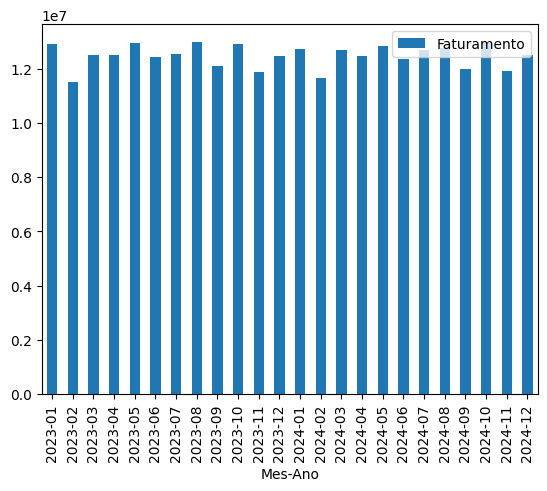

In [ ]:
# analise de faturamento por mes
analise_df['Mes-Ano'] = analise_df['Data'].dt.to_period('M')
analise_mes = analise_df[['Mes-Ano','Faturamento']].groupby('Mes-Ano').sum()
analise_mes.plot(kind='bar')
display(analise_df)
display(analise_mes)